# Лабораторная работа 4

**Авдиенко, Говоров, Сигаева | К3240**

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from io import StringIO

In [ ]:
# размер датасета и типы данных
df = pd.read_csv("Sleep_Health_and_Lifestyle_Dataset.csv")

print(df.shape)
display(df.dtypes)


Файл успешно загружен!
(374, 13)


,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


## Гипотезы

1. **Качество сна важнее длительности сна** - Quality of Sleep сильнее влияет на уровень стресса, чем Sleep Duration<br><br>
2. **Физическая активность компенсирует часть негативных эффектов** - при более высоком Physical_Activity_Level качество сна выше, стресса меньше, лучше давление и пульс<br><br>
3. **Физическая активность влияет на количество сна** - люди с высоким Physical Activity Level спят больше<br><br>
4. **Высокий стресс является причиной проблем со сном** - у людей с высоким Stress Level наблюдаются нарушения сна<br><br>
5. **BMI связан с ухудшением сна и самочувствия** - более высокий BMI (индекс массы тела) влияет на уменьшение продолжительности сна и ухудшает качество сна<br><br>
6. **Профессия влияет на уровень стресса** - люди, работа которых связана с высокой социальной ответственностью (доктора, учителя, медсёстры), имеют наивысший уровень стресса<br><br>
7. **Прямая зависимость возраста и качества сна** - с возрастом качество сна улучшается (или стабилизируется), так как более зрелые участники могут иметь более налаженный режим дня<br><br>
8. **Более высокая осознанность женщин** - женщины чаще сообщают о нарушениях сна (Sleep Disorder), таких как бессонница, и пытаются с ними бороться по сравнению с мужчинами<br><br>
9. **Болезнь и повышенное давление связаны** - высокое кровяное давление (выше 130/85) напрямую связано с наличием апноэ сна<br><br>
10. **Образ жизни определяет BMI** - люди, ведущие сидячий образ жизни (мало шагов), чаще имеют категорию BMI Obese<br><br>
11. **Категория BMI связана с частотой пульса** — у людей с разными категориями BMI отличается Heart Rate, при более высоком BMI пульс может быть выше<br><br>
12. **Чем выше частота пульса, тем ниже качество сна** — высокий Heart Rate связан с более низким Quality of Sleep<br><br>
13. **У людей с высоким BMI выше уровень стресса** — люди с категорией BMI Overweight или Obese имеют более высокий Stress Level<br><br>
14. **У разных профессий разные типы нарушений сна** — распределение Sleep Disorder отличается в зависимости от Occupation<br><br>
15. **У разных профессий отличается уровень физической активности** — представители разных Occupation имеют разный Physical Activity Level


### Качество сна важнее длительности сна

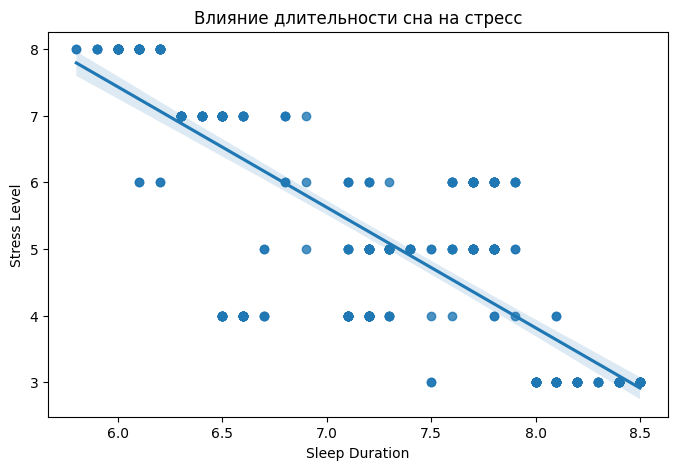

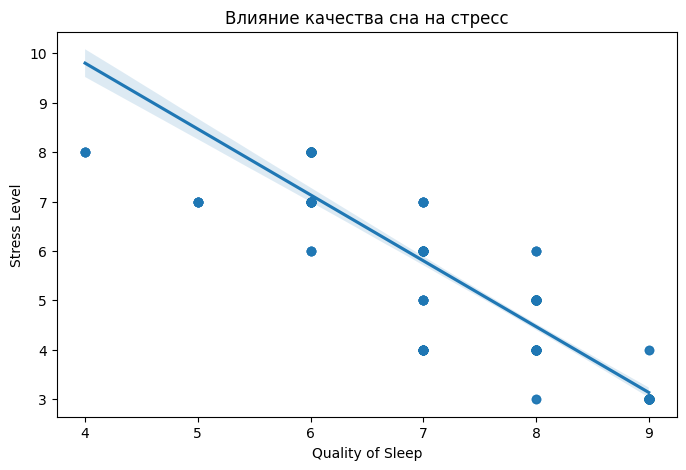

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Sleep Duration", y="Stress Level")
plt.title("Влияние длительности сна на стресс")
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Quality of Sleep", y="Stress Level")
plt.title("Влияние качества сна на стресс")
plt.xlabel("Quality of Sleep")
plt.ylabel("Stress Level")
plt.show()

**Вывод**
На обоих графиках наблюдается отрицательная связь между показателями сна и уровнем стресса: чем больше сна и лучше качество - тем менше стресса. При этом связь качества сна и уровня стресса вяглядит более выраженной.

Можно утверждать, что гипотеза подтвердилась


### Физическая активность компенсирует часть негативных эффектов

,Physical Activity Level,Quality of Sleep,Stress Level,Heart Rate,Systolic_BP
Physical Activity Level,1.000000,0.192896,-0.034134,0.136971,0.265416
Quality of Sleep,0.192896,1.000000,-0.898752,-0.659865,-0.121632
Stress Level,-0.034134,-0.898752,1.000000,0.670026,0.102818
Heart Rate,0.136971,-0.659865,0.670026,1.000000,0.294143
Systolic_BP,0.265416,-0.121632,0.102818,0.294143,1.000000


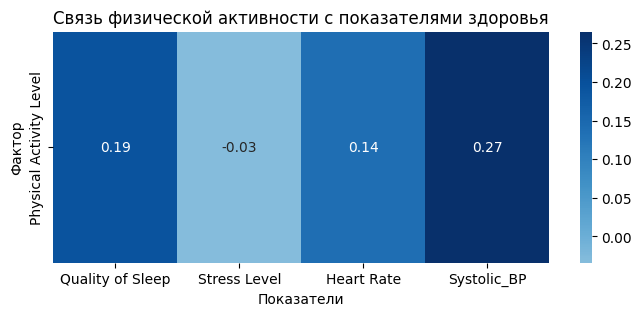

In [ ]:
df["Systolic_BP"] = df["Blood Pressure"].apply(lambda x: int(x.split("/")[0]))

corr_data = df[["Physical Activity Level", "Quality of Sleep", "Stress Level", "Heart Rate", "Systolic_BP"]].corr()
display(corr_data)

corr_compare = corr_data.loc[["Physical Activity Level"], ["Quality of Sleep", "Stress Level", "Heart Rate", "Systolic_BP"]]

plt.figure(figsize=(8, 3))
sns.heatmap(corr_compare, annot=True, cmap="Blues", fmt=".2f", center=0)
plt.title("Связь физической активности с показателями здоровья")
plt.xlabel("Показатели")
plt.ylabel("Фактор")
plt.show()

**Вывод**

Уровень физической активности имеет слабую положительную связь с качеством сна и почти не связан со стрессом. Средне-слабая связь наблюдается между физической активностью и давлением.

Гипотеза не подтвердлиась, в этом датасете уровень физической активности не влияет или влияет слабо на уровень стресса, сердцебиение и остальные показатели



### Физическая активность влияет на количество сна

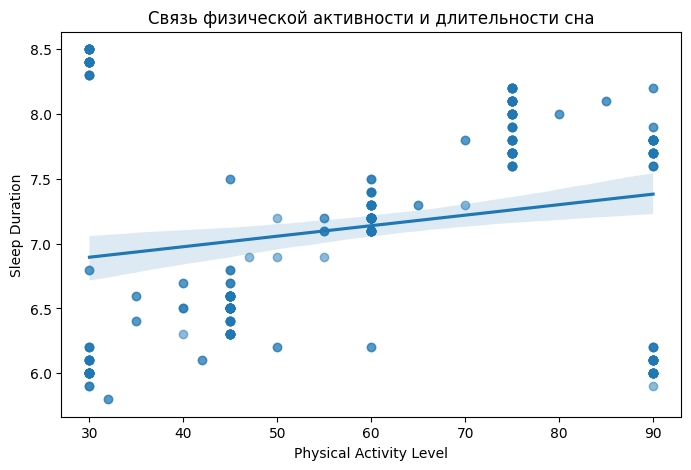

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Physical Activity Level", y="Sleep Duration", scatter_kws={"alpha": 0.5})
plt.title("Связь физической активности и длительности сна")
plt.xlabel("Physical Activity Level")
plt.ylabel("Sleep Duration")
plt.show()

**Вывод**

На графике видна слабая положительная связь между уровнем физической активности и длительностью сна. При увеличении уровня физическо активности, длительность сна в среднем немного растет

Гипотеза подтвердилась, в данном датасете люди с более высоким уровнем физической активности спят дольше

### Высокий стресс является причиной проблем со сном

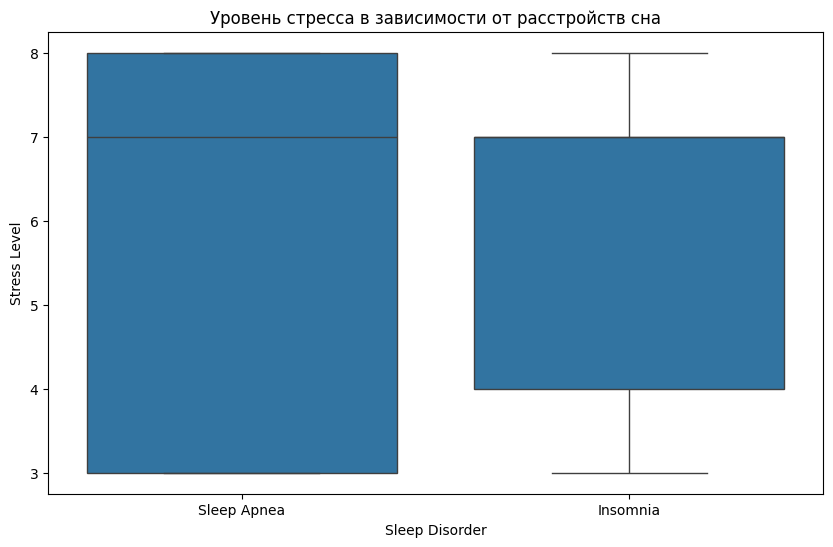

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Sleep Disorder", y="Stress Level")
plt.title("Уровень стресса в зависимости от расстройств сна")
plt.xlabel("Sleep Disorder")
plt.ylabel("Stress Level")
plt.show()

**Вывод**

На boxplot видно, что у участников без расстройства сна медианный уровень стресса ниже, чем у людей с бессонницей или апноэ. Медианный уровеня стресса у людей с апноэ самый высокий, мединанный уровень бессонницы совпал с верхней границей боксплота.

Можно сделать вывод, что гипотеза подтвердилась -  наличие расстройств сна связано с более высоким уровнем стресса.


### BMI связан с ухудшением сна и самочувствия

In [ ]:
import plotly.express as px

df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")

fig = px.box(
    df,
    x="BMI Category",
    y="Sleep Duration",
    points="all",
    title="BMI и длительность сна"
)

fig.show()

На boxplot видно, что у группы Normal длительность сна в среднем выше, чем у Overweight. У группы Obese разброс значений больше, но явного преимущества по длительности сна также не наблюдается.

In [ ]:
fig = px.box(
    df,
    x="BMI Category",
    y="Quality of Sleep",
    points="all",
    title="BMI и качество сна"
)

fig.show()

На boxplot видно, что у группы Normal качество сна в среднем выше, чем у Overweight и Obese. У группы Obese значения качества сна наиболее низкие, а у Normal распределение смещено вверх и выглядит более стабильным.

**Вывод**

Гипотеза в целом подтвердилась. Нормальный BMI связан с более благоприятными показателями сна, тогда как при избыточной массе тела и ожирении длительность и особенно качество сна в среднем хуже.


### Профессия влияет на уровень стресса

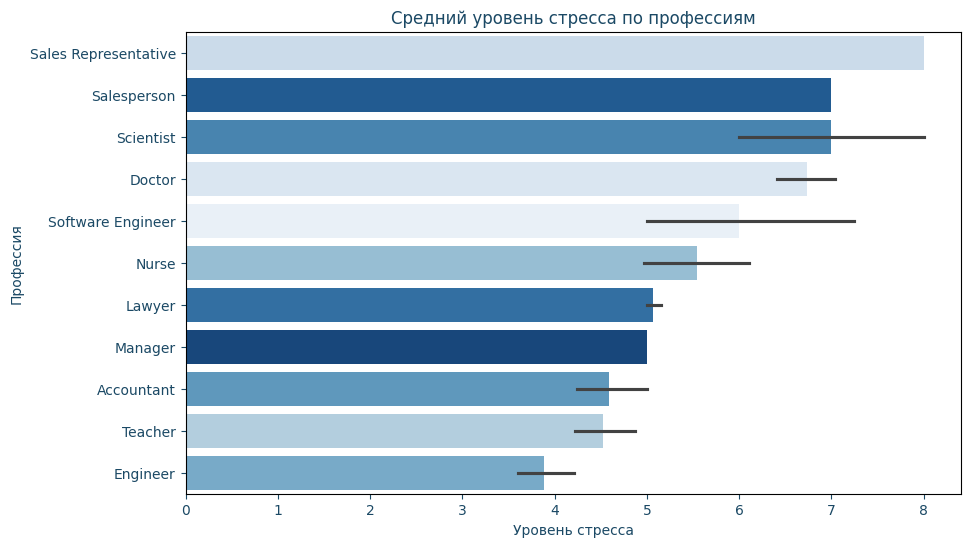

In [ ]:
plt.figure(figsize=(10, 6))
order = df.groupby('Occupation')['Stress Level'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='Stress Level', y='Occupation', order=order,
            hue='Occupation', palette='Blues', legend=False, dodge=False)
plt.title('Средний уровень стресса по профессиям', color='#1B4965')
plt.xlabel('Уровень стресса', color='#1B4965')
plt.ylabel('Профессия', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод**

Как видно по столбчатой диаграмме, наивысший уровень стресса у представителей продаж (Sales Representative и Salesperson), далее у ученых и потом только у докторов. А у учителей в данном датасете вообще один из самых низких. Таким образом, гипотеза подтвердилась личь частично (у врачей повышенный уровень стресса, но не самый высокий).

### Прямая зависимость возраста и качества сна

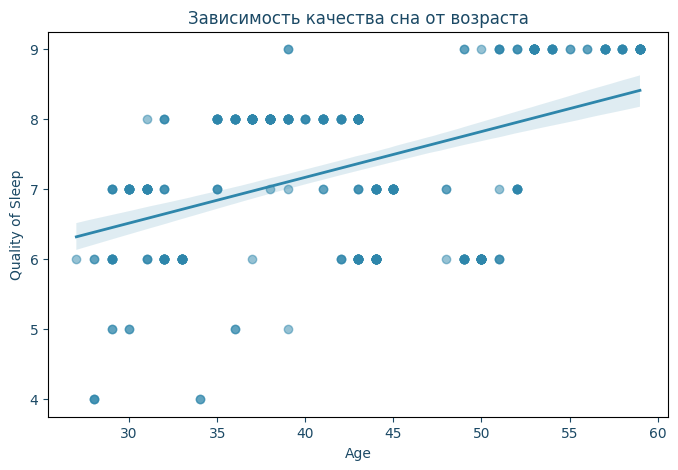

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Age', y='Quality of Sleep',
            color='#2E86AB',
            scatter_kws={'alpha':0.5},
            line_kws={'linewidth':2})
plt.title('Зависимость качества сна от возраста', color='#1B4965', fontsize=12)
plt.xlabel('Age', color='#1B4965')
plt.ylabel('Quality of Sleep', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод**

На данном графике видна достаточно выраженная положительная зависимость качества сна `Quality of Sleep` от возраста `Age`. Гипотеза действительно подтвердилась на этот датасете.

### Более высокая осознанность женщин

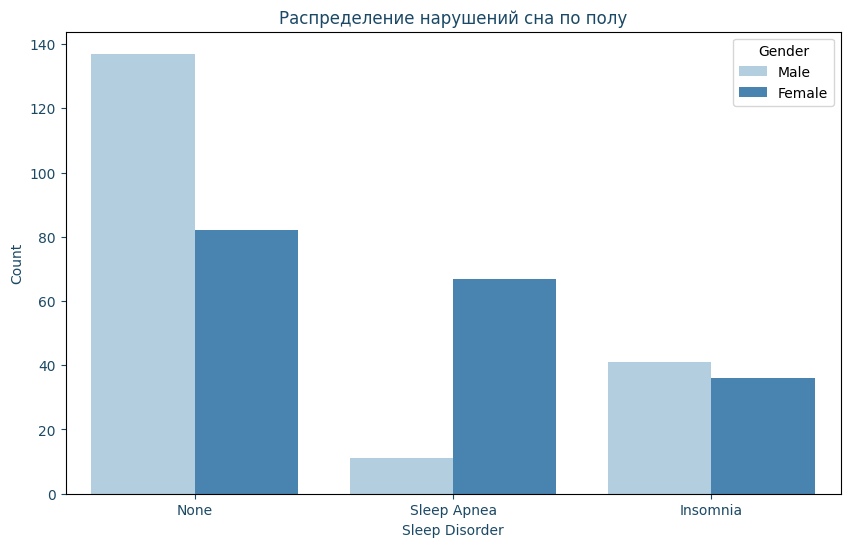

In [ ]:
plt.figure(figsize=(10, 6))
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
sns.countplot(data=df, x='Sleep Disorder', hue='Gender', palette='Blues')
plt.title('Распределение нарушений сна по полу', color='#1B4965')
plt.xlabel('Sleep Disorder', color='#1B4965')
plt.ylabel('Count', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.legend(title='Gender')
plt.show()

**Вывод**

На countplot мы видим, что у мужчин более высокий столбец с отсутствием болезней. Однако если посмотреть на сравнения в апноэ и бессонице, то бессоницей страдает в этом датасете больше мужчин, а апноэ женщин. Таким образом, гипотеза частично подтвердилась.

### Болезнь и повышенное давление связаны

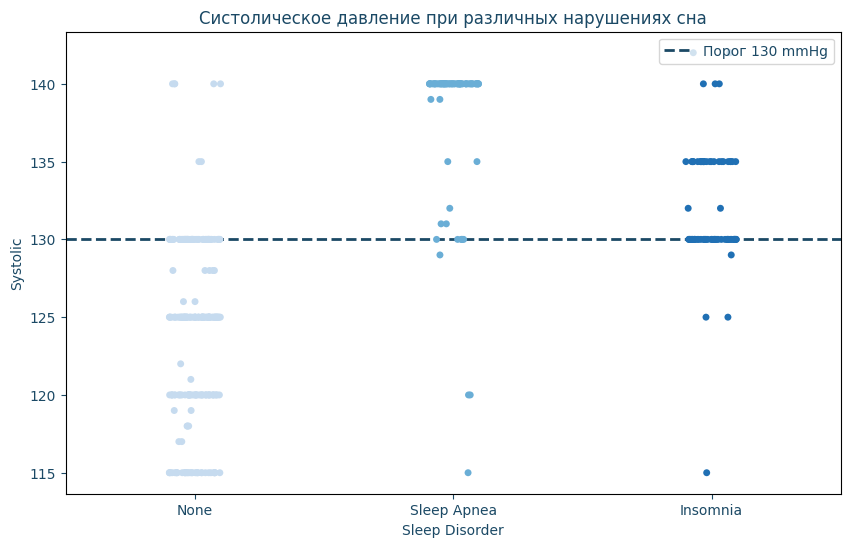

In [ ]:
df['Systolic'] = df['Blood Pressure'].apply(lambda x: int(x.split('/')[0]))

plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='Sleep Disorder', y='Systolic', jitter=True,
              hue='Sleep Disorder', palette='Blues', legend=False)
plt.axhline(y=130, color='#1B4965', linestyle='--', linewidth=2, label='Порог 130 mmHg')
plt.title('Систолическое давление при различных нарушениях сна', color='#1B4965', fontsize=12)
plt.xlabel('Sleep Disorder', color='#1B4965')
plt.ylabel('Systolic', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.legend(loc='upper right', labelcolor='#1B4965')
plt.show()

**Вывод**

По графику мы видим, что у людей с болезнями сна действительно повыщенное верхнее (систолическое) давление: у тех, кто страдает от апноэ, оно наиболее высокое, у людей с бессоницей - на грани или повышенное. Гипотеза подтвердилась.

### Образ жизни определяет BMI

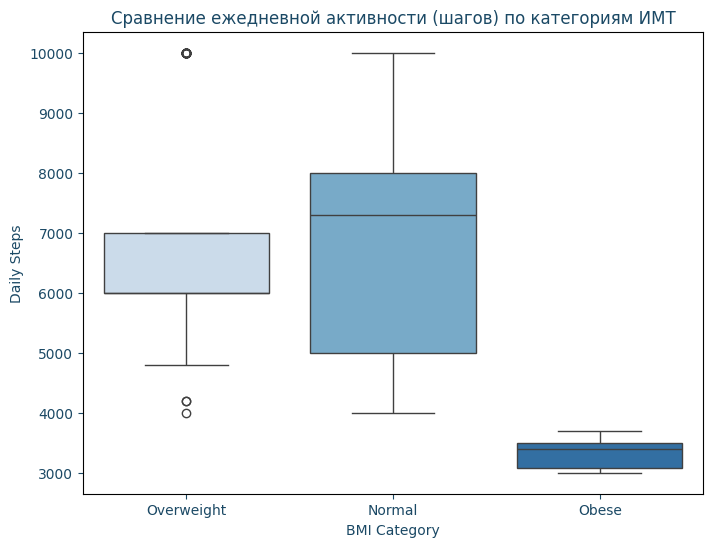

In [ ]:
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='BMI Category', y='Daily Steps',
            hue='BMI Category', palette='Blues', legend=False)
plt.title('Сравнение ежедневной активности (шагов) по категориям ИМТ', color='#1B4965')
plt.xlabel('BMI Category', color='#1B4965')
plt.ylabel('Daily Steps', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод**

На boxplot видно, что больше всего активность (шаги) у людей с нормальным весом. У тех, кто имеет категорию Obese, количество шагов минимальное среди всех. Однако у людей с повышенной массой тела активность примерно средняя. В целом гипотеза подтвердилась.

### Категория BMI связана с частотой пульса

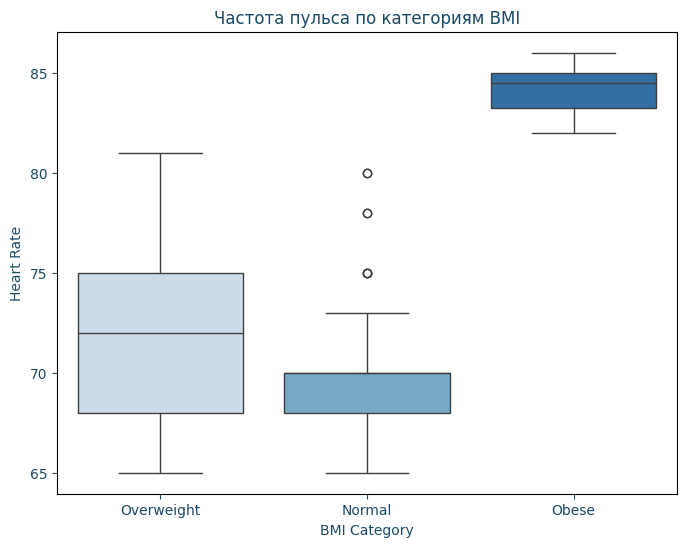

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='BMI Category', y='Heart Rate',
            hue='BMI Category', palette='Blues', legend=False)
plt.title('Частота пульса по категориям BMI', color='#1B4965')
plt.xlabel('BMI Category', color='#1B4965')
plt.ylabel('Heart Rate', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод:** у разных категорий BMI частота пульса отличается. У людей с более высокой категорией BMI пульс в среднем выше, поэтому гипотеза подтвердилась.

### Чем выше частота пульса, тем ниже качество сна

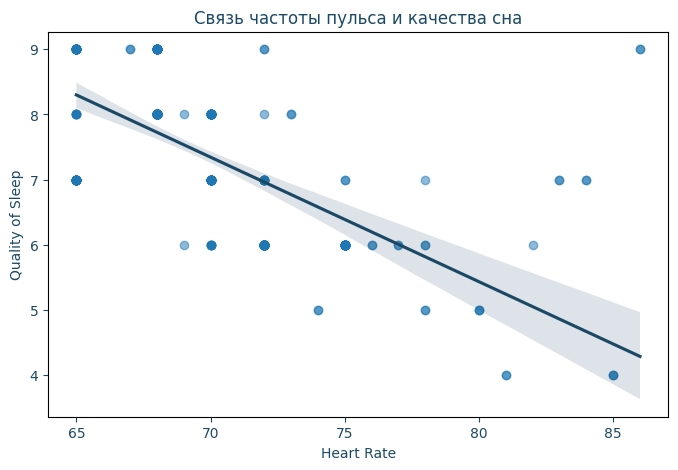

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Heart Rate', y='Quality of Sleep',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': '#1B4965'})
plt.title('Связь частоты пульса и качества сна', color='#1B4965')
plt.xlabel('Heart Rate', color='#1B4965')
plt.ylabel('Quality of Sleep', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод**: при увеличении частоты пульса качество сна снижается, поэтому гипотеза подтвердилась

### У людей с высоким BMI выше уровень стресса

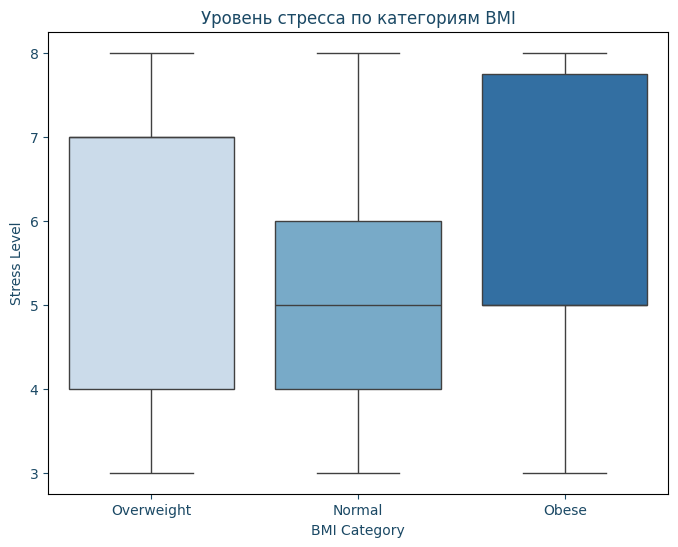

In [ ]:
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='BMI Category', y='Stress Level',
            hue='BMI Category', palette='Blues', legend=False)
plt.title('Уровень стресса по категориям BMI', color='#1B4965')
plt.xlabel('BMI Category', color='#1B4965')
plt.ylabel('Stress Level', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод**: у людей с более высокой категорией BMI уровень стресса чаще выше, поэтому гипотеза подтвердилась.

### У разных профессий разные типы нарушений сна

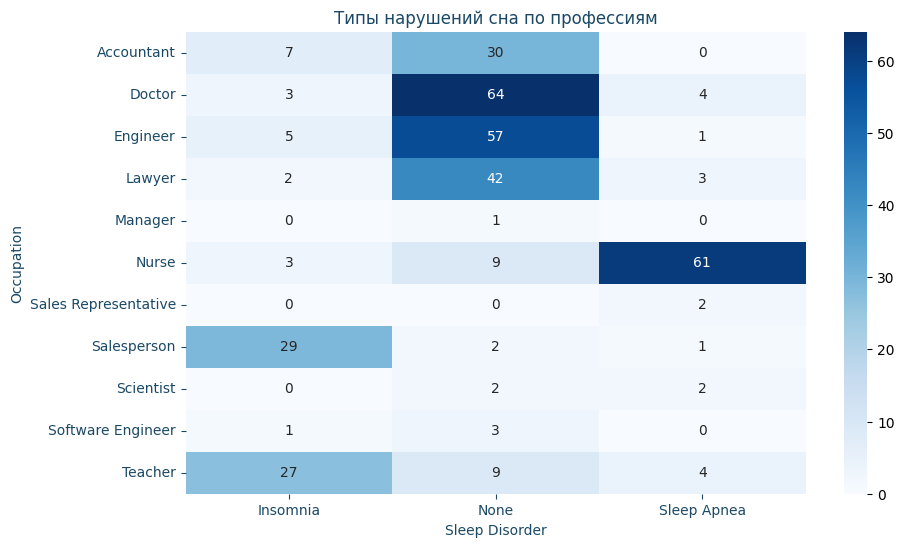

In [ ]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

sleep_occ = pd.crosstab(df['Occupation'], df['Sleep Disorder'])

plt.figure(figsize=(10, 6))
sns.heatmap(sleep_occ, annot=True, cmap='Blues', fmt='d')
plt.title('Типы нарушений сна по профессиям', color='#1B4965')
plt.xlabel('Sleep Disorder', color='#1B4965')
plt.ylabel('Occupation', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод**: у разных профессий преобладают разные типы нарушений сна. Например, у Nurses чаще встречается Sleep Apnea, а у Salesperson и Teacher чаще встречается Insomnia, поэтому гипотеза подтвердилась

### У разных профессий отличается уровень физической активности

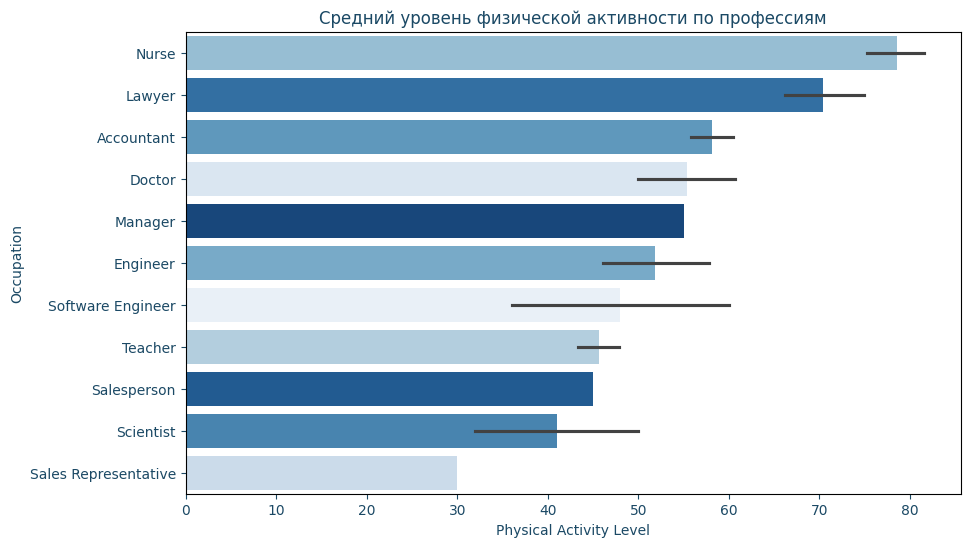

In [ ]:
plt.figure(figsize=(10, 6))
order = df.groupby('Occupation')['Physical Activity Level'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='Physical Activity Level', y='Occupation', order=order,
            hue='Occupation', palette='Blues', legend=False)
plt.title('Средний уровень физической активности по профессиям', color='#1B4965')
plt.xlabel('Physical Activity Level', color='#1B4965')
plt.ylabel('Occupation', color='#1B4965')
plt.tick_params(colors='#1B4965')
plt.show()

**Вывод:** у разных профессий средний уровень физической активности отличается: одни профессии связаны с более активным образом жизни, другие — с менее активным, поэтому гипотеза подтвердилась.

### Гипотезы в порядке значимости

1. **У разных профессий разные типы нарушений сна** — распределение Sleep Disorder отличается в зависимости от Occupation<br><br>
2. **Прямая зависимость возраста и качества сна** - с возрастом качество сна улучшается (или стабилизируется), так как более зрелые участники могут иметь более налаженный режим дня<br><br>
3. **BMI связан с ухудшением сна и самочувствия** - более высокий BMI (индекс массы тела) влияет на уменьшение продолжительности сна и ухудшает качество сна<br><br>
4. **Качество сна важнее длительности сна** - Quality of Sleep сильнее влияет на уровень стресса, чем Sleep Duration<br><br>
5. **Профессия влияет на уровень стресса** - люди, работа которых связана с высокой социальной ответственностью (доктора, учителя, медсёстры), имеют наивысший уровень стресса<br><br>
6. **У людей с высоким BMI выше уровень стресса** — люди с категорией BMI Overweight или Obese имеют более высокий Stress Level<br><br>
7. **У разных профессий отличается уровень физической активности** — представители разных Occupation имеют разный Physical Activity Level
8. **Физическая активность влияет на количество сна** - люди с высоким Physical Activity Level спят больше<br><br>
9. **Болезнь и повышенное давление связаны** - высокое кровяное давление (выше 130/85) напрямую связано с наличием апноэ сна<br><br>
10. **Физическая активность компенсирует часть негативных эффектов** - при более высоком Physical_Activity_Level качество сна выше, стресса меньше, лучше давление и пульс<br><br>
11. **Высокий стресс является причиной проблем со сном** - у людей с высоким Stress Level наблюдаются нарушения сна<br><br>
12. **Чем выше частота пульса, тем ниже качество сна** — высокий Heart Rate связан с более низким Quality of Sleep<br><br>
12. **У людей с высоким BMI выше уровень стресса** — люди с категорией BMI Overweight или Obese имеют более высокий Stress Level<br><br>
14. **Образ жизни определяет BMI** - люди, ведущие сидячий образ жизни (мало шагов), чаще имеют категорию BMI Obese<br><br>
15. **Более высокая осознанность женщин** - женщины чаще сообщают о нарушениях сна (Sleep Disorder), таких как бессонница, и пытаются с ними бороться по сравнению с мужчинами